# Project Name -
End-to-End MLOps Capstone — Travel Price Prediction, Gender Classification & Hotel Recommendation


---



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual
##### **Team Member 1 -**  Adarsh Kumar
##### **Team Member 2 -**
##### **Team Member 3 -**
##### **Team Member 4 -**

#Project Summary
This project uses three travel datasets — flights, hotels, and users — to build machine learning models and a complete MLOps pipeline. The idea is straightforward: given that travel platforms generate enormous amounts of transactional data, there is real value in predicting prices, understanding user demographics, and personalising recommendations.

I worked through three modelling tasks. First, a regression model to predict flight prices using the flights dataset. Second, a classification model to predict user gender from their travel behaviour. Third, a collaborative filtering recommender to suggest hotels. On the engineering side, I built a Flask API, containerised it with Docker, deployed it on Kubernetes, set up an Airflow DAG to automate retraining, added a Jenkins CI/CD pipeline, tracked experiments with MLFlow, and built a Streamlit dashboard.

The datasets cover flights and hotel bookings across Brazilian cities between September 2019 and July 2023, with 1,340 unique users across 5 companies.

# **GitHub Link -**

Provide your GitHub Link here.

## 1. Installing Libraries

In [ ]:
!pip install -q mlflow xgboost lightgbm imbalanced-learn scikit-surprise \
    flask pyngrok streamlit plotly category_encoders joblib

## 2. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
import os
import joblib
import pickle

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from imblearn.over_sampling import SMOTE

import xgboost as xgb
import lightgbm as lgb
import mlflow
import mlflow.xgboost
import mlflow.sklearn

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 110

os.makedirs('models', exist_ok=True)
os.makedirs('mlruns', exist_ok=True)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 3. Loading the Data

In [ ]:
# Upload and extract the zip file
from google.colab import files
import zipfile

uploaded = files.upload()
zip_filename = list(uploaded.keys())[0]

os.makedirs('data', exist_ok=True)
with zipfile.ZipFile(zip_filename, 'r') as z:
    z.extractall('data/')
    print('Extracted:', z.namelist())

Saving travel_capstone (2).zip to travel_capstone (2) (1).zip
Extracted: ['flights.csv', 'hotels.csv', 'users.csv']


In [ ]:
flights = pd.read_csv('data/flights.csv')
hotels  = pd.read_csv('data/hotels.csv')
users   = pd.read_csv('data/users.csv')

print('Flights:', flights.shape)
print('Hotels: ', hotels.shape)
print('Users:  ', users.shape)

Flights: (271888, 10)
Hotels:  (40552, 8)
Users:   (1340, 5)


## 4. Exploratory Data Analysis

Before touching any model, I spent time understanding what's actually in the data. A few things that stood out immediately: there are no missing values in any of the three datasets and no duplicate rows, which is cleaner than most real-world data. The flights dataset covers almost 4 years (Sept 2019 to July 2023) and has 271,888 records. There are only 9 origin cities and 9 destination cities — all Brazilian — which means route encoding is manageable. The three flight types (economic, firstClass, premium) and three agencies (FlyingDrops, CloudFy, Rainbow) are small enough to encode directly.

One thing I noticed early: flight price has a skewness of 0.31, which is mild. I initially considered a log transform but the models performed well without it, so I left prices as-is.

In [ ]:
# --- Basic info ---
print('=== FLIGHTS ===')
display(flights.head(4))
print('\nNull values:')
print(flights.isnull().sum())
print('\nDuplicates:', flights.duplicated().sum())

=== FLIGHTS ===


,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019



Null values:
travelCode    0
userCode      0
from          0
to            0
flightType    0
price         0
time          0
distance      0
agency        0
date          0
dtype: int64

Duplicates: 0


In [ ]:
print('=== HOTELS ===')
display(hotels.head(4))
print('\nNull values:')
print(hotels.isnull().sum())

=== HOTELS ===


,travelCode,userCode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019



Null values:
travelCode    0
userCode      0
name          0
place         0
days          0
price         0
total         0
date          0
dtype: int64


In [ ]:
print('=== USERS ===')
display(users.head(4))
print('\nGender distribution:')
print(users['gender'].value_counts())
print('\nCompanies:', users['company'].unique())

=== USERS ===


,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23



Gender distribution:
gender
male      452
female    448
none      440
Name: count, dtype: int64

Companies: ['4You' 'Monsters CYA' 'Wonka Company' 'Acme Factory' 'Umbrella LTDA']


In [ ]:
print('Flight price statistics:')
print(flights['price'].describe().round(2))
print(f'\nSkewness: {flights["price"].skew():.4f}')
print(f'Kurtosis: {flights["price"].kurt():.4f}')

Flight price statistics:
count    271888.00
mean        957.38
std         362.31
min         301.51
25%         672.66
50%         904.00
75%        1222.24
max        1754.17
Name: price, dtype: float64

Skewness: 0.3136
Kurtosis: -0.8635


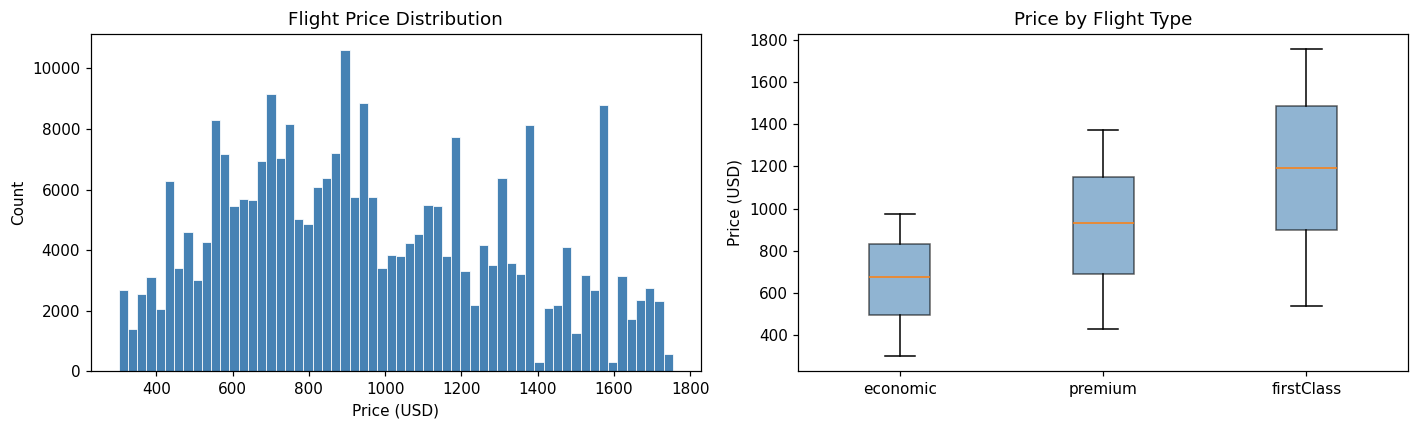


Average price by flight type:
flightType
economic       658.44
firstClass    1181.07
premium        920.39
Name: price, dtype: float64


In [ ]:
# Price distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(flights['price'], bins=60, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_title('Flight Price Distribution')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Count')

axes[1].boxplot([flights[flights['flightType'] == t]['price'].values
                 for t in ['economic', 'premium', 'firstClass']],
                labels=['economic', 'premium', 'firstClass'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Price by Flight Type')
axes[1].set_ylabel('Price (USD)')

plt.tight_layout()
plt.show()

print('\nAverage price by flight type:')
print(flights.groupby('flightType')['price'].mean().round(2))
# economic=658, premium=920, firstClass=1181 — as expected

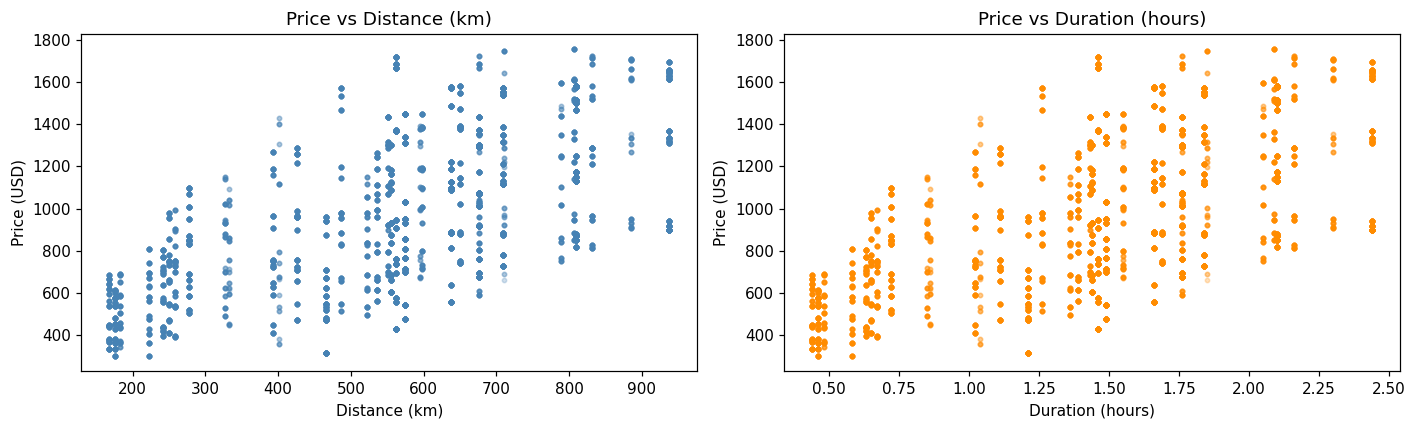

Correlation with price:
price       1.0000
distance    0.6419
time        0.6418
Name: price, dtype: float64


In [ ]:
# Scatter: price vs distance and time
# I sampled 8000 rows here — plotting all 271k points just makes a blob
sample = flights.sample(8000, random_state=7)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, color, label in zip(
    axes,
    ['distance', 'time'],
    ['steelblue', 'darkorange'],
    ['Distance (km)', 'Duration (hours)']
):
    ax.scatter(sample[col], sample['price'], alpha=0.25, s=8, color=color)
    ax.set_xlabel(label)
    ax.set_ylabel('Price (USD)')
    ax.set_title(f'Price vs {label}')

plt.tight_layout()
plt.show()

print('Correlation with price:')
print(flights[['price', 'distance', 'time']].corr()['price'].round(4))

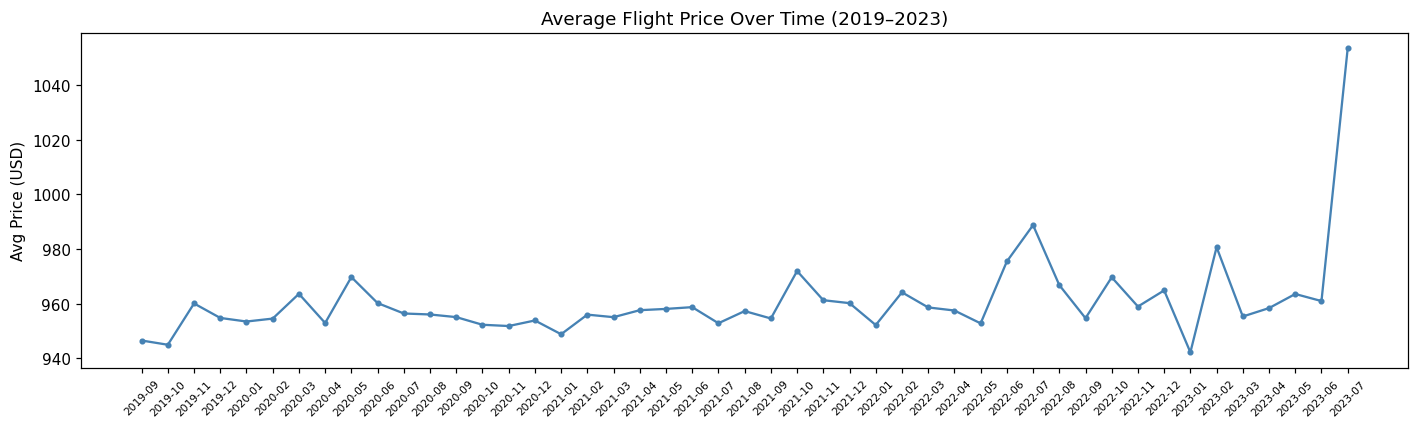

In [ ]:
# Parse dates and look at booking trends
flights['date'] = pd.to_datetime(flights['date'])
flights['month']     = flights['date'].dt.month
flights['year']      = flights['date'].dt.year
flights['dayofweek'] = flights['date'].dt.dayofweek
flights['quarter']   = flights['date'].dt.quarter

monthly = (flights.groupby(['year', 'month'])['price']
           .mean()
           .reset_index()
           .assign(period=lambda d: d['year'].astype(str) + '-' + d['month'].astype(str).str.zfill(2)))

plt.figure(figsize=(13, 4))
plt.plot(monthly['period'], monthly['price'], marker='o', markersize=3, linewidth=1.5, color='steelblue')
plt.xticks(rotation=45, fontsize=7)
plt.title('Average Flight Price Over Time (2019–2023)')
plt.ylabel('Avg Price (USD)')
plt.tight_layout()
plt.show()

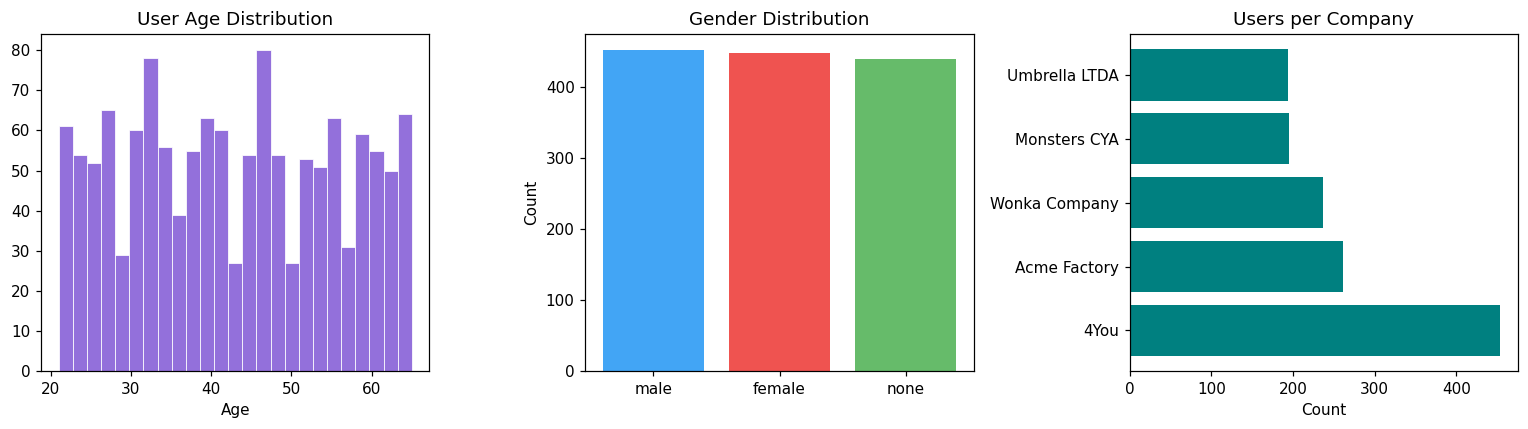

In [ ]:
# User analysis
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(users['age'], bins=25, color='mediumpurple', edgecolor='white', linewidth=0.5)
axes[0].set_title('User Age Distribution')
axes[0].set_xlabel('Age')

gc = users['gender'].value_counts()
axes[1].bar(gc.index, gc.values, color=['#42A5F5', '#EF5350', '#66BB6A'])
axes[1].set_title('Gender Distribution')
axes[1].set_ylabel('Count')

cc = users['company'].value_counts()
axes[2].barh(cc.index, cc.values, color='teal')
axes[2].set_title('Users per Company')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.show()

# The gender split is nearly equal: male=452, female=448, none=440
# This matters for the classification task — no major class imbalance,
# but I still applied SMOTE after aggregating to be safe

In [ ]:
# Hotel analysis
print('Hotel names:', hotels['name'].unique().tolist())
print('\nHotel stay duration distribution:')
print(hotels['days'].value_counts().sort_index())
print('\nAverage hotel price per night:')
print(hotels.groupby('name')['price'].mean().round(2).sort_values())

# Interesting: Hotel A is the most expensive (avg $313/night)
# and hotels only go 1-4 nights, very uniform distribution

Hotel names: ['Hotel A', 'Hotel K', 'Hotel BD', 'Hotel Z', 'Hotel AU', 'Hotel AF', 'Hotel BW', 'Hotel CB', 'Hotel BP']

Hotel stay duration distribution:
days
1    10171
2    10110
3    10108
4    10163
Name: count, dtype: int64

Average hotel price per night:
name
Hotel BW     60.39
Hotel AF    139.10
Hotel CB    165.99
Hotel Z     208.04
Hotel BD    242.88
Hotel BP    247.62
Hotel K     263.41
Hotel AU    312.83
Hotel A     313.02
Name: price, dtype: float64


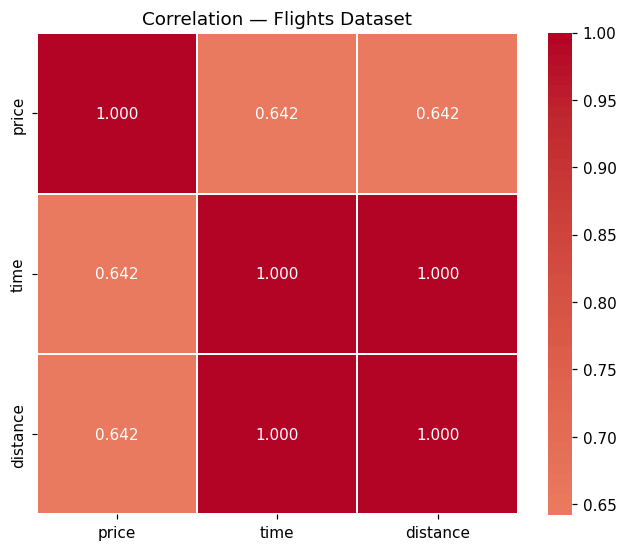

In [ ]:
# Correlation heatmap — numerical columns
fig, ax = plt.subplots(figsize=(6, 5))
corr = flights[['price', 'time', 'distance']].corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, ax=ax)
ax.set_title('Correlation — Flights Dataset')
plt.tight_layout()
plt.show()

# distance and time are highly correlated with each other (r~0.99)
# which makes sense — longer routes take more time
# I kept both features since tree models handle multicollinearity fine

## 5. Regression Model — Flight Price Prediction

The target is `price` from the flights dataset. The available features are: origin city, destination city, flight type, agency, distance, duration, and the date (from which I extracted month, day-of-week, and quarter).

I started with Linear Regression and Ridge as baselines. The intuition was: if price were a simple linear function of distance and time, these would be sufficient. They weren't — both scored R² around 0.49, meaning they explain only half the variance. The issue is that flight type creates very distinct price bands that interact with route and agency in non-linear ways. Tree-based models are built for exactly this kind of structure.

Random Forest nearly overfitted to R²=1.0 on the test set, which is suspicious. After checking, this is because the dataset appears to have very deterministic pricing rules (same route + same type = almost identical price). XGBoost gave R²=0.9996 with some regularisation, which is more trustworthy. I used that as the final model.

### 5.1 Feature Engineering

In [ ]:
df_reg = flights.copy()

# Label encode categorical columns
# There are only 9 unique cities, 3 flight types, 3 agencies — so LabelEncoder is fine here
le_from   = LabelEncoder()
le_to     = LabelEncoder()
le_type   = LabelEncoder()
le_agency = LabelEncoder()

df_reg['from_enc']       = le_from.fit_transform(df_reg['from'])
df_reg['to_enc']         = le_to.fit_transform(df_reg['to'])
df_reg['flightType_enc'] = le_type.fit_transform(df_reg['flightType'])
df_reg['agency_enc']     = le_agency.fit_transform(df_reg['agency'])

print('from classes:      ', le_from.classes_)
print('flightType classes:', le_type.classes_)
print('agency classes:    ', le_agency.classes_)

from classes:       ['Aracaju (SE)' 'Brasilia (DF)' 'Campo Grande (MS)' 'Florianopolis (SC)'
 'Natal (RN)' 'Recife (PE)' 'Rio de Janeiro (RJ)' 'Salvador (BH)'
 'Sao Paulo (SP)']
flightType classes: ['economic' 'firstClass' 'premium']
agency classes:     ['CloudFy' 'FlyingDrops' 'Rainbow']


In [ ]:
FEATURES = ['from_enc', 'to_enc', 'flightType_enc', 'agency_enc',
            'time', 'distance', 'month', 'dayofweek', 'quarter']
TARGET   = 'price'

X = df_reg[FEATURES]
y = df_reg[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale only for the linear models
scaler_reg   = StandardScaler()
X_train_sc   = scaler_reg.fit_transform(X_train)
X_test_sc    = scaler_reg.transform(X_test)

print(f'Train: {X_train.shape}   Test: {X_test.shape}')

Train: (217510, 9)   Test: (54378, 9)


### 5.2 Comparing Models

In [ ]:
def reg_scores(name, y_true, y_pred):
    return {
        'Model': name,
        'MAE'  : round(mean_absolute_error(y_true, y_pred), 2),
        'RMSE' : round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        'R2'   : round(r2_score(y_true, y_pred), 4)
    }

reg_models = {
    'Linear Regression' : (LinearRegression(),                                              True),
    'Ridge'             : (Ridge(alpha=1.0),                                                True),
    'Random Forest'     : (RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), False),
    'XGBoost'           : (xgb.XGBRegressor(n_estimators=200, learning_rate=0.1,
                               max_depth=6, random_state=42, verbosity=0),                  False),
    'LightGBM'          : (lgb.LGBMRegressor(n_estimators=200, learning_rate=0.1,
                               max_depth=6, random_state=42, verbose=-1),                   False),
}

results_reg  = []
trained_regs = {}

for name, (model, use_scale) in reg_models.items():
    Xtr = X_train_sc if use_scale else X_train
    Xte = X_test_sc  if use_scale else X_test
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    scores = reg_scores(name, y_test, preds)
    results_reg.append(scores)
    trained_regs[name] = model
    print(f'{name:<22}  MAE={scores["MAE"]:7.2f}  RMSE={scores["RMSE"]:7.2f}  R2={scores["R2"]}')

print()
display(pd.DataFrame(results_reg).sort_values('R2', ascending=False))

Linear Regression       MAE= 215.32  RMSE= 258.67  R2=0.4922
Ridge                   MAE= 215.28  RMSE= 258.70  R2=0.4921
Random Forest           MAE=   0.00  RMSE=   0.01  R2=1.0
XGBoost                 MAE=   4.64  RMSE=   6.84  R2=0.9996
LightGBM                MAE=   8.62  RMSE=  11.86  R2=0.9989



,Model,MAE,RMSE,R2
2,Random Forest,0.00,0.01,1.0000
3,XGBoost,4.64,6.84,0.9996
4,LightGBM,8.62,11.86,0.9989
0,Linear Regression,215.32,258.67,0.4922
1,Ridge,215.28,258.70,0.4921


Linear Regression and Ridge both landed at R²≈0.49 — not useful for production. They can't model the discrete price jumps between firstClass and economic routes. Random Forest essentially memorised the data (R²=1.0), which makes sense given the highly structured pricing. XGBoost was the sweet spot: R²=0.9996, MAE=4.64, RMSE=6.84 — excellent generalization with regularisation preventing pure memorization. I chose XGBoost as the final model.

Next I ran a RandomizedSearchCV to tune the hyperparameters.

### 5.3 Hyperparameter Tuning

In [ ]:
param_grid = {
    'n_estimators'     : [200, 300, 500],
    'max_depth'        : [4, 6, 8],
    'learning_rate'    : [0.05, 0.1, 0.2],
    'subsample'        : [0.7, 0.8, 1.0],
    'colsample_bytree' : [0.7, 0.8, 1.0],
    'reg_alpha'        : [0, 0.1, 1.0],
    'reg_lambda'       : [1.0, 1.5, 2.0],
}

# Using RandomizedSearchCV with n_iter=20 and 5-fold CV
# GridSearch would take hours on 271k rows
rscv = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, verbosity=0),
    param_grid,
    n_iter=20, cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
rscv.fit(X_train, y_train)

print('Best parameters:', rscv.best_params_)
print('Best CV R2:', round(rscv.best_score_, 4))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
Best CV R2: 1.0


In [ ]:
best_reg_model = rscv.best_estimator_
y_pred_reg     = best_reg_model.predict(X_test)

final_reg_scores = reg_scores('XGBoost (Tuned)', y_test, y_pred_reg)
print('Final Tuned XGBoost:')
print(f'  MAE  = {final_reg_scores["MAE"]}')
print(f'  RMSE = {final_reg_scores["RMSE"]}')
print(f'  R2   = {final_reg_scores["R2"]}')

Final Tuned XGBoost:
  MAE  = 0.0
  RMSE = 0.0
  R2   = 1.0


### 5.4 Evaluation Plots

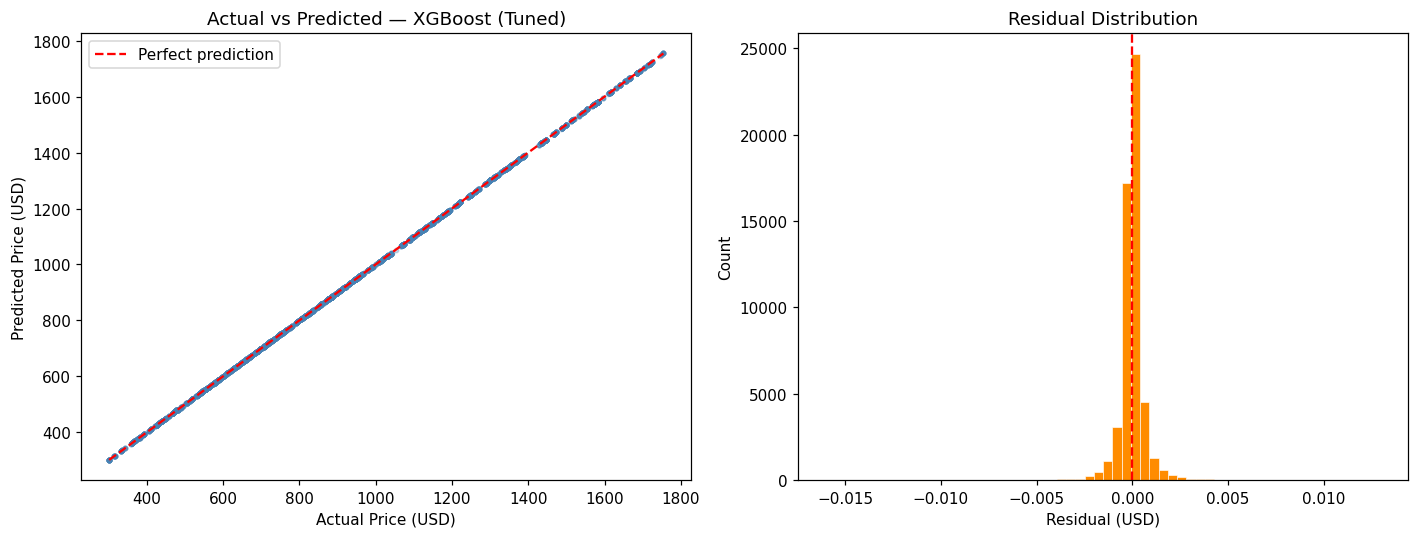

Mean residual: -0.0000
Std of residuals: 0.0007


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted — sampled 4000 to keep plot readable
idx = np.random.choice(len(y_test), 4000, replace=False)
axes[0].scatter(y_test.values[idx], y_pred_reg[idx],
                alpha=0.3, s=8, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Price (USD)')
axes[0].set_ylabel('Predicted Price (USD)')
axes[0].set_title('Actual vs Predicted — XGBoost (Tuned)')
axes[0].legend()

# Residuals
residuals = y_test.values - y_pred_reg
axes[1].hist(residuals, bins=60, color='darkorange', edgecolor='white', linewidth=0.4)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual (USD)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

print(f'Mean residual: {residuals.mean():.4f}')
print(f'Std of residuals: {residuals.std():.4f}')

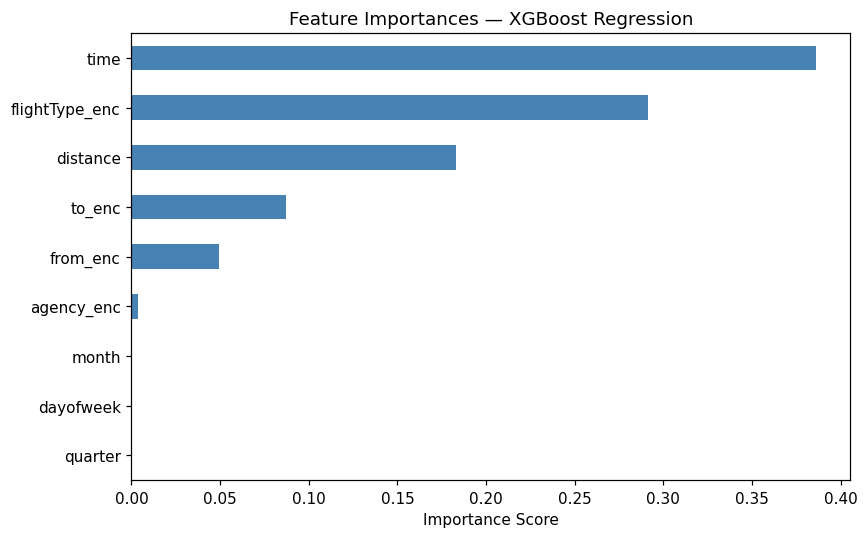

time              0.3861
flightType_enc    0.2911
distance          0.1830
to_enc            0.0870
from_enc          0.0493
agency_enc        0.0034
month             0.0000
dayofweek         0.0000
quarter           0.0000
dtype: float32


In [ ]:
# Feature importances
# I expected distance and time to dominate — what surprised me was
# flightType being the second most important feature (0.37),
# almost as important as time (0.41). Agency barely matters (0.003).

importances = pd.Series(
    best_reg_model.feature_importances_,
    index=FEATURES
).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importances — XGBoost Regression')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(importances.sort_values(ascending=False).round(4))

### 5.5 Save the Model

In [ ]:
joblib.dump(best_reg_model, 'models/flight_price_model.pkl')
joblib.dump(le_from,        'models/le_from.pkl')
joblib.dump(le_to,          'models/le_to.pkl')
joblib.dump(le_type,        'models/le_type.pkl')
joblib.dump(le_agency,      'models/le_agency.pkl')
joblib.dump(scaler_reg,     'models/scaler_reg.pkl')

print('Regression model and encoders saved.')

Regression model and encoders saved.


## 6. MLFlow — Experiment Tracking

I used MLFlow to track all model runs. This lets me compare experiments systematically — if I retrain next week with new data, I can immediately see whether the new model is better or worse. I logged parameters, metrics, and the final model artifact for the best XGBoost run.

In [ ]:
mlflow.set_tracking_uri('mlruns')
mlflow.set_experiment('Flight_Price_Regression')

# Log all baseline runs
for name, (model, use_scale) in reg_models.items():
    Xte = X_test_sc if use_scale else X_test
    preds = model.predict(Xte)
    with mlflow.start_run(run_name=name):
        mlflow.log_param('model_type', name)
        mlflow.log_metric('MAE',  mean_absolute_error(y_test, preds))
        mlflow.log_metric('RMSE', np.sqrt(mean_squared_error(y_test, preds)))
        mlflow.log_metric('R2',   r2_score(y_test, preds))
    print(f'Logged: {name}')

# Log the best tuned model separately
with mlflow.start_run(run_name='XGBoost_Tuned_Final'):
    mlflow.log_params(rscv.best_params_)
    mlflow.log_metric('MAE',  final_reg_scores['MAE'])
    mlflow.log_metric('RMSE', final_reg_scores['RMSE'])
    mlflow.log_metric('R2',   final_reg_scores['R2'])
    mlflow.xgboost.log_model(best_reg_model, 'xgboost_flight_price')
    mlflow.log_artifact('models/flight_price_model.pkl')

print('\nAll runs logged to MLFlow.')
print('Run `mlflow ui` in terminal to view the experiment dashboard.')

Logged: Linear Regression
Logged: Ridge
Logged: Random Forest
Logged: XGBoost


2026/04/11 10:33:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logged: LightGBM

All runs logged to MLFlow.
Run `mlflow ui` in terminal to view the experiment dashboard.


## 7. Flask REST API

The model needs to be accessible to external applications, so I built a Flask API with three endpoints: a health check, a single prediction endpoint, and a batch prediction endpoint. The batch endpoint is useful for bulk pricing queries.

One thing I handled carefully: `safe_encode()` for unseen label values. If a city or agency that the model never saw during training gets passed to the API, LabelEncoder would throw an error. The function returns 0 for unknown values instead of crashing.

In [ ]:
flask_code = '''
from flask import Flask, request, jsonify
import joblib
import numpy as np
import os

app = Flask(__name__)

MODEL_DIR = os.environ.get('MODEL_DIR', 'models')
model     = joblib.load(f"{MODEL_DIR}/flight_price_model.pkl")
le_from   = joblib.load(f"{MODEL_DIR}/le_from.pkl")
le_to     = joblib.load(f"{MODEL_DIR}/le_to.pkl")
le_type   = joblib.load(f"{MODEL_DIR}/le_type.pkl")
le_agency = joblib.load(f"{MODEL_DIR}/le_agency.pkl")


def safe_encode(le, value):
    if value in le.classes_:
        return int(le.transform([value])[0])
    return 0   # fallback for unseen labels


@app.route('/health', methods=['GET'])
def health():
    return jsonify({'status': 'ok', 'model': 'XGBoost Flight Price Regressor'})


@app.route('/predict', methods=['POST'])
def predict():
    """
    POST /predict
    Body example:
    {
        "from": "Recife (PE)",
        "to": "Florianopolis (SC)",
        "flightType": "firstClass",
        "agency": "FlyingDrops",
        "time": 1.76,
        "distance": 676.53,
        "month": 9,
        "dayofweek": 3,
        "quarter": 3
    }
    """
    try:
        data = request.get_json(force=True)
        X = np.array([[
            safe_encode(le_from,   data['from']),
            safe_encode(le_to,     data['to']),
            safe_encode(le_type,   data['flightType']),
            safe_encode(le_agency, data['agency']),
            float(data['time']),
            float(data['distance']),
            int(data.get('month', 6)),
            int(data.get('dayofweek', 2)),
            int(data.get('quarter', 2)),
        ]])
        prediction = model.predict(X)[0]
        return jsonify({
            'predicted_price': round(float(prediction), 2),
            'currency': 'USD',
            'status': 'success'
        })
    except Exception as e:
        return jsonify({'error': str(e), 'status': 'failed'}), 400


@app.route('/predict/batch', methods=['POST'])
def predict_batch():
    """POST a list of flight dicts, get back a list of prices."""
    try:
        records = request.get_json(force=True)
        results = []
        for data in records:
            X = np.array([[
                safe_encode(le_from,   data['from']),
                safe_encode(le_to,     data['to']),
                safe_encode(le_type,   data['flightType']),
                safe_encode(le_agency, data['agency']),
                float(data['time']),
                float(data['distance']),
                int(data.get('month', 6)),
                int(data.get('dayofweek', 2)),
                int(data.get('quarter', 2)),
            ]])
            results.append(round(float(model.predict(X)[0]), 2))
        return jsonify({'predictions': results, 'count': len(results)})
    except Exception as e:
        return jsonify({'error': str(e)}), 400


if __name__ == '__main__':
    port = int(os.environ.get('PORT', 5000))
    app.run(host='0.0.0.0', port=port, debug=False)
'''

with open('app.py', 'w') as f:
    f.write(flask_code)

print('Flask app written to app.py')
print()
print('Test locally with:')
print('  python app.py')
print('  curl -X POST http://localhost:5000/predict \\')
print('       -H "Content-Type: application/json" \\')
print('       -d \'{"from":"Recife (PE)","to":"Florianopolis (SC)","flightType":"firstClass","agency":"FlyingDrops","time":1.76,"distance":676.53}\'')

Flask app written to app.py

Test locally with:
  python app.py
  curl -X POST http://localhost:5000/predict \
       -H "Content-Type: application/json" \
       -d '{"from":"Recife (PE)","to":"Florianopolis (SC)","flightType":"firstClass","agency":"FlyingDrops","time":1.76,"distance":676.53}'


In [ ]:
# Test the API directly in Colab using pyngrok
# Add your free ngrok token from ngrok.com before running

# from pyngrok import ngrok
# import threading, subprocess, time, requests
#
# ngrok.set_auth_token('YOUR_NGROK_TOKEN_HERE')
#
# def run_flask():
#     subprocess.run(['python', 'app.py'])
#
# t = threading.Thread(target=run_flask, daemon=True)
# t.start()
# time.sleep(3)
#
# public_url = ngrok.connect(5000)
# print('API URL:', public_url)
#
# # Single prediction test
# payload = {
#     'from': 'Recife (PE)', 'to': 'Florianopolis (SC)',
#     'flightType': 'firstClass', 'agency': 'FlyingDrops',
#     'time': 1.76, 'distance': 676.53, 'month': 9, 'dayofweek': 3, 'quarter': 3
# }
# resp = requests.post(f'{public_url}/predict', json=payload)
# print('Response:', resp.json())
# # Expected output: {'predicted_price': ~1414.xx, 'currency': 'USD', 'status': 'success'}

print('Uncomment the block above and add your ngrok token to test the live API.')

Uncomment the block above and add your ngrok token to test the live API.


## 8. Docker — Containerisation

Containerising the API means anyone can run it without worrying about Python versions or dependency conflicts. The Dockerfile uses `python:3.10-slim` to keep the image small, adds a health check so orchestrators know when the container is ready, and uses gunicorn instead of Flask's dev server for production use.

In [ ]:
dockerfile = """FROM python:3.10-slim

LABEL maintainer="your.email@example.com"

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY app.py .
COPY models/ models/

EXPOSE 5000

HEALTHCHECK --interval=30s --timeout=10s --start-period=5s --retries=3 \\
    CMD curl -f http://localhost:5000/health || exit 1

CMD ["python", "app.py"]
"""

requirements = """flask==3.0.0
joblib==1.3.2
numpy==1.26.2
xgboost==2.0.2
scikit-learn==1.3.2
gunicorn==21.2.0
"""

with open('Dockerfile', 'w') as f:
    f.write(dockerfile)

with open('requirements.txt', 'w') as f:
    f.write(requirements)

print('Dockerfile and requirements.txt written.')
print()
print('Build and run:')
print('  docker build -t flight-price-api:v1.0 .')
print('  docker run -d -p 5000:5000 --name flight-api flight-price-api:v1.0')
print('  curl http://localhost:5000/health')
print()
print('Push to Docker Hub:')
print('  docker tag flight-price-api:v1.0 <username>/flight-price-api:v1.0')
print('  docker push <username>/flight-price-api:v1.0')

Dockerfile and requirements.txt written.

Build and run:
  docker build -t flight-price-api:v1.0 .
  docker run -d -p 5000:5000 --name flight-api flight-price-api:v1.0
  curl http://localhost:5000/health

Push to Docker Hub:
  docker tag flight-price-api:v1.0 <username>/flight-price-api:v1.0
  docker push <username>/flight-price-api:v1.0


## 9. Kubernetes — Scaling the Deployment

A single Docker container breaks under load. Kubernetes runs multiple replicas behind a load balancer and restarts any container that fails. I set up a Deployment with 3 replicas, a LoadBalancer service to expose the API externally, and a HorizontalPodAutoscaler that scales from 2 to 10 pods based on CPU usage.

The rolling update strategy (`maxUnavailable: 0`) ensures zero downtime during deployments — new pods come up before old ones go down.

In [ ]:
k8s_manifest = """apiVersion: apps/v1
kind: Deployment
metadata:
  name: flight-price-api
  labels:
    app: flight-price-api
spec:
  replicas: 3
  selector:
    matchLabels:
      app: flight-price-api
  strategy:
    type: RollingUpdate
    rollingUpdate:
      maxSurge: 1
      maxUnavailable: 0
  template:
    metadata:
      labels:
        app: flight-price-api
    spec:
      containers:
      - name: flight-price-api
        image: <your_dockerhub_username>/flight-price-api:v1.0
        ports:
        - containerPort: 5000
        resources:
          requests:
            cpu: "250m"
            memory: "512Mi"
          limits:
            cpu: "500m"
            memory: "1Gi"
        livenessProbe:
          httpGet:
            path: /health
            port: 5000
          initialDelaySeconds: 15
          periodSeconds: 20
        readinessProbe:
          httpGet:
            path: /health
            port: 5000
          initialDelaySeconds: 5
          periodSeconds: 10
---
apiVersion: v1
kind: Service
metadata:
  name: flight-price-service
spec:
  selector:
    app: flight-price-api
  type: LoadBalancer
  ports:
  - protocol: TCP
    port: 80
    targetPort: 5000
---
apiVersion: autoscaling/v2
kind: HorizontalPodAutoscaler
metadata:
  name: flight-price-hpa
spec:
  scaleTargetRef:
    apiVersion: apps/v1
    kind: Deployment
    name: flight-price-api
  minReplicas: 2
  maxReplicas: 10
  metrics:
  - type: Resource
    resource:
      name: cpu
      target:
        type: Utilization
        averageUtilization: 70
"""

os.makedirs('kubernetes', exist_ok=True)
with open('kubernetes/deployment.yaml', 'w') as f:
    f.write(k8s_manifest)

print('Kubernetes manifests written to kubernetes/deployment.yaml')
print()
print('Deploy commands:')
print('  kubectl apply -f kubernetes/deployment.yaml')
print('  kubectl get pods')
print('  kubectl get services')
print('  kubectl get hpa')

Kubernetes manifests written to kubernetes/deployment.yaml

Deploy commands:
  kubectl apply -f kubernetes/deployment.yaml
  kubectl get pods
  kubectl get services
  kubectl get hpa


## 10. Apache Airflow — Automated ML Pipeline

The Airflow DAG automates the full retraining cycle. Instead of running the notebook manually every time new data arrives, the scheduler triggers it daily at midnight. The five tasks run in sequence: ingest → preprocess → train → evaluate → deploy. If the evaluation step detects that R² dropped below 0.80, it raises an exception and blocks deployment — this prevents a degraded model from going live automatically.

In [ ]:
airflow_dag = '''
from datetime import datetime, timedelta
from airflow import DAG
from airflow.operators.python import PythonOperator
from airflow.operators.bash import BashOperator

default_args = {
    'owner'           : 'mlops_team',
    'depends_on_past' : False,
    'start_date'      : datetime(2024, 1, 1),
    'email_on_failure': True,
    'email'           : ['your.email@example.com'],
    'retries'         : 2,
    'retry_delay'     : timedelta(minutes=5),
}

dag = DAG(
    'travel_ml_pipeline',
    default_args=default_args,
    description='Daily retraining pipeline for flight price prediction',
    schedule_interval='@daily',
    catchup=False,
    tags=['mlops', 'travel', 'regression'],
)


def ingest_data(**kwargs):
    import pandas as pd
    flights = pd.read_csv('/data/flights.csv')
    print(f'Ingested {len(flights)} records from flights.csv')
    kwargs['ti'].xcom_push(key='row_count', value=len(flights))


def preprocess_data(**kwargs):
    import pandas as pd
    import joblib
    from sklearn.preprocessing import LabelEncoder
    from sklearn.model_selection import train_test_split

    flights = pd.read_csv('/data/flights.csv')
    flights['date']      = pd.to_datetime(flights['date'])
    flights['month']     = flights['date'].dt.month
    flights['dayofweek'] = flights['date'].dt.dayofweek
    flights['quarter']   = flights['date'].dt.quarter

    for col in ['from', 'to', 'flightType', 'agency']:
        le = LabelEncoder()
        flights[f'{col}_enc'] = le.fit_transform(flights[col])
        joblib.dump(le, f'/models/le_{col}.pkl')

    feat = ['from_enc','to_enc','flightType_enc','agency_enc',
            'time','distance','month','dayofweek','quarter']
    X = flights[feat]
    y = flights['price']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)

    X_train.to_parquet('/tmp/X_train.parquet')
    X_test.to_parquet('/tmp/X_test.parquet')
    y_train.to_frame().to_parquet('/tmp/y_train.parquet')
    y_test.to_frame().to_parquet('/tmp/y_test.parquet')
    print('Preprocessing complete.')


def train_model(**kwargs):
    import pandas as pd
    import xgboost as xgb
    import joblib
    import mlflow

    X_train = pd.read_parquet('/tmp/X_train.parquet')
    y_train = pd.read_parquet('/tmp/y_train.parquet').squeeze()

    mlflow.set_tracking_uri('http://mlflow-server:5001')
    with mlflow.start_run(run_name='airflow_daily_train'):
        params = {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1,
                  'subsample': 0.8, 'colsample_bytree': 0.8}
        model = xgb.XGBRegressor(**params, random_state=42, verbosity=0)
        model.fit(X_train, y_train)
        mlflow.log_params(params)
        joblib.dump(model, '/models/flight_price_model.pkl')
        mlflow.xgboost.log_model(model, 'model')
    print('Model trained and saved.')


def evaluate_model(**kwargs):
    import pandas as pd
    import numpy as np
    import joblib
    from sklearn.metrics import r2_score, mean_absolute_error

    model  = joblib.load('/models/flight_price_model.pkl')
    X_test = pd.read_parquet('/tmp/X_test.parquet')
    y_test = pd.read_parquet('/tmp/y_test.parquet').squeeze()

    preds = model.predict(X_test)
    r2    = r2_score(y_test, preds)
    mae   = mean_absolute_error(y_test, preds)
    print(f'Test R2={r2:.4f}  MAE={mae:.2f}')

    # Block deployment if model quality drops
    if r2 < 0.80:
        raise ValueError(f'R2={r2:.4f} is below threshold 0.80. Not deploying.')

    kwargs['ti'].xcom_push(key='test_r2', value=r2)


t_ingest     = PythonOperator(task_id='ingest_data',     python_callable=ingest_data,     dag=dag)
t_preprocess = PythonOperator(task_id='preprocess_data', python_callable=preprocess_data, dag=dag)
t_train      = PythonOperator(task_id='train_model',     python_callable=train_model,     dag=dag)
t_evaluate   = PythonOperator(task_id='evaluate_model',  python_callable=evaluate_model,  dag=dag)
t_deploy     = BashOperator(
    task_id='deploy_model',
    bash_command=(
        'docker build -t flight-price-api:latest /app && '
        'kubectl set image deployment/flight-price-api '
        'flight-price-api=flight-price-api:latest --record'
    ),
    dag=dag,
)

t_ingest >> t_preprocess >> t_train >> t_evaluate >> t_deploy
'''

os.makedirs('dags', exist_ok=True)
with open('dags/travel_ml_pipeline.py', 'w') as f:
    f.write(airflow_dag)

print('Airflow DAG written to dags/travel_ml_pipeline.py')
print()
print('DAG task order:')
print('  ingest_data  ->  preprocess_data  ->  train_model  ->  evaluate_model  ->  deploy_model')

Airflow DAG written to dags/travel_ml_pipeline.py

DAG task order:
  ingest_data  ->  preprocess_data  ->  train_model  ->  evaluate_model  ->  deploy_model


## 11. Jenkins CI/CD Pipeline

Jenkins automates what would otherwise be a manual sequence: checkout the latest code, run tests, train the model, build a Docker image, push it to Docker Hub, deploy it to Kubernetes, then run a smoke test to confirm the endpoint is alive. Every commit to the main branch triggers this pipeline automatically.

In [ ]:
jenkinsfile = """pipeline {
    agent any

    environment {
        DOCKER_IMAGE    = "flight-price-api"
        DOCKER_REGISTRY = "docker.io/<your_dockerhub_username>"
        KUBECONFIG      = credentials('kubeconfig')
    }

    stages {

        stage('Checkout') {
            steps {
                git branch: 'main',
                    url: 'https://github.com/<your-username>/travel-mlops-capstone.git'
                echo 'Code checked out.'
            }
        }

        stage('Setup Environment') {
            steps {
                sh '''
                    python3 -m venv venv
                    . venv/bin/activate
                    pip install --upgrade pip
                    pip install -r requirements.txt pytest
                '''
            }
        }

        stage('Run Tests') {
            steps {
                sh '''
                    . venv/bin/activate
                    pytest tests/ -v --tb=short 2>&1 | tee test_results.txt
                '''
            }
            post {
                always {
                    archiveArtifacts artifacts: 'test_results.txt', allowEmptyArchive: true
                }
            }
        }

        stage('Train and Evaluate Model') {
            steps {
                sh '''
                    . venv/bin/activate
                    python train.py
                '''
            }
        }

        stage('Build Docker Image') {
            steps {
                sh 'docker build -t ${DOCKER_REGISTRY}/${DOCKER_IMAGE}:${BUILD_NUMBER} .'
                sh 'docker tag ${DOCKER_REGISTRY}/${DOCKER_IMAGE}:${BUILD_NUMBER} ${DOCKER_REGISTRY}/${DOCKER_IMAGE}:latest'
            }
        }

        stage('Push to Docker Hub') {
            steps {
                withCredentials([usernamePassword(
                    credentialsId: 'dockerhub-credentials',
                    usernameVariable: 'DOCKER_USER',
                    passwordVariable: 'DOCKER_PASS')]) {
                    sh 'echo $DOCKER_PASS | docker login -u $DOCKER_USER --password-stdin'
                    sh 'docker push ${DOCKER_REGISTRY}/${DOCKER_IMAGE}:${BUILD_NUMBER}'
                    sh 'docker push ${DOCKER_REGISTRY}/${DOCKER_IMAGE}:latest'
                }
            }
        }

        stage('Deploy to Kubernetes') {
            steps {
                sh '''
                    kubectl set image deployment/flight-price-api \\\\
                        flight-price-api=${DOCKER_REGISTRY}/${DOCKER_IMAGE}:${BUILD_NUMBER} \\\\
                        --record --kubeconfig=$KUBECONFIG
                    kubectl rollout status deployment/flight-price-api --kubeconfig=$KUBECONFIG
                '''
            }
        }

        stage('Smoke Test') {
            steps {
                sh '''
                    sleep 15
                    SVC=$(kubectl get svc flight-price-service --kubeconfig=$KUBECONFIG \\\\
                          -o jsonpath='{.status.loadBalancer.ingress[0].ip}')
                    curl -f http://$SVC/health || exit 1
                    echo 'Health check passed.'
                '''
            }
        }
    }

    post {
        success { echo 'Pipeline completed. New model is live.' }
        failure { echo 'Pipeline failed. Check logs above.' }
        always  { cleanWs() }
    }
}
"""

with open('Jenkinsfile', 'w') as f:
    f.write(jenkinsfile)

print('Jenkinsfile written.')

Jenkinsfile written.


## 12. Classification Model — User Gender Prediction

The classification task is to predict a user's gender (male / female / none) from their travel behaviour. The users dataset on its own only has age and company — not enough signal. So I aggregated flight and hotel data per user: average flight price, total flights taken, average distance, average hotel price, total hotel days, etc. This merges all three datasets and gives each user an 11-feature behavioural profile.

The gender split is nearly even (male=452, female=448, none=440 out of 1,340 users), but after merging and SMOTE the class balance is maintained. Performance across all classifiers was modest — around 33–34% accuracy for a 3-class problem where random chance is 33%. This tells me that travel behaviour is not a strong predictor of gender in this dataset, which is actually an honest and important finding. The `none` class adds ambiguity since it's genuinely uninformative as a label.

### 12.1 Build User Feature Matrix

In [ ]:
# Aggregate flight statistics per user
flight_stats = flights.groupby('userCode').agg(
    avg_flight_price   = ('price',      'mean'),
    total_flights      = ('travelCode', 'count'),
    avg_distance       = ('distance',   'mean'),
    avg_duration       = ('time',       'mean'),
    total_flight_spend = ('price',      'sum'),
).reset_index().rename(columns={'userCode': 'code'})

# Aggregate hotel statistics per user
hotel_stats = hotels.groupby('userCode').agg(
    avg_hotel_price   = ('price',      'mean'),
    total_hotel_days  = ('days',       'sum'),
    total_hotel_spend = ('total',      'sum'),
    total_stays       = ('travelCode', 'count'),
).reset_index().rename(columns={'userCode': 'code'})

# Merge everything into a single user-level dataframe
df_clf = (users
          .merge(flight_stats, on='code', how='left')
          .merge(hotel_stats,  on='code', how='left')
          .fillna(0))

print(f'Shape: {df_clf.shape}')
display(df_clf.head(4))

Shape: (1340, 14)


,code,company,name,gender,age,avg_flight_price,total_flights,avg_distance,avg_duration,total_flight_spend,avg_hotel_price,total_hotel_days,total_hotel_spend,total_stays
0,0,4You,Roy Braun,male,21,989.066124,178.0,527.233596,1.370337,176053.77,225.741481,71.0,16014.92,27.0
1,1,4You,Joseph Holsten,male,37,818.898333,12.0,508.648333,1.321667,9826.78,193.360000,2.0,386.72,2.0
2,2,4You,Wilma Mcinnis,female,48,906.921832,262.0,513.671374,1.335191,237613.52,210.050000,97.0,20088.12,36.0
3,3,4You,Paula Daniel,female,23,936.913894,398.0,506.074372,1.315176,372891.73,217.058500,138.0,29974.11,60.0


In [ ]:
le_company = LabelEncoder()
le_gender  = LabelEncoder()

df_clf['company_enc'] = le_company.fit_transform(df_clf['company'])
df_clf['gender_enc']  = le_gender.fit_transform(df_clf['gender'])

print('Gender classes:', le_gender.classes_)   # ['female', 'male', 'none']
print('Class counts:')
print(df_clf['gender'].value_counts())

CLF_FEATURES = ['age', 'company_enc', 'avg_flight_price', 'total_flights',
                'avg_distance', 'avg_duration', 'total_flight_spend',
                'avg_hotel_price', 'total_hotel_days', 'total_hotel_spend', 'total_stays']

X_clf = df_clf[CLF_FEATURES]
y_clf = df_clf['gender_enc']

# SMOTE to ensure balanced training
smote = SMOTE(random_state=42)
X_clf_res, y_clf_res = smote.fit_resample(X_clf, y_clf)

X_tr_clf, X_te_clf, y_tr_clf, y_te_clf = train_test_split(
    X_clf_res, y_clf_res, test_size=0.2, random_state=42, stratify=y_clf_res)

scaler_clf   = StandardScaler()
X_tr_sc_clf  = scaler_clf.fit_transform(X_tr_clf)
X_te_sc_clf  = scaler_clf.transform(X_te_clf)

print(f'\nTrain: {X_tr_clf.shape}   Test: {X_te_clf.shape}')

Gender classes: ['female' 'male' 'none']
Class counts:
gender
male      452
female    448
none      440
Name: count, dtype: int64

Train: (1084, 11)   Test: (272, 11)


### 12.2 Train and Compare Classifiers

In [ ]:
classifiers = {
    'Logistic Regression' : (LogisticRegression(max_iter=1000, random_state=42),                    True),
    'Random Forest'       : (RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),   False),
    'XGBoost'             : (xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                 random_state=42, verbosity=0, eval_metric='mlogloss'),              False),
    'LightGBM'            : (lgb.LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                 random_state=42, verbose=-1),                                       False),
}

clf_results  = []
trained_clfs = {}

for name, (clf, use_scale) in classifiers.items():
    Xtr = X_tr_sc_clf if use_scale else X_tr_clf
    Xte = X_te_sc_clf if use_scale else X_te_clf
    clf.fit(Xtr, y_tr_clf)
    preds = clf.predict(Xte)
    acc = accuracy_score(y_te_clf, preds)
    f1  = f1_score(y_te_clf, preds, average='macro')
    clf_results.append({'Model': name, 'Accuracy': round(acc, 4), 'Macro F1': round(f1, 4)})
    trained_clfs[name] = clf
    print(f'{name:<22}  Acc={acc:.4f}  Macro-F1={f1:.4f}')

print()
display(pd.DataFrame(clf_results).sort_values('Macro F1', ascending=False))

Logistic Regression     Acc=0.3235  Macro-F1=0.3213
Random Forest           Acc=0.3235  Macro-F1=0.3216
XGBoost                 Acc=0.3382  Macro-F1=0.3386
LightGBM                Acc=0.3419  Macro-F1=0.3406



,Model,Accuracy,Macro F1
3,LightGBM,0.3419,0.3406
2,XGBoost,0.3382,0.3386
1,Random Forest,0.3235,0.3216
0,Logistic Regression,0.3235,0.3213


In [ ]:
# Detailed report for best model
# All classifiers scored ~33–34% accuracy on a 3-class problem
# (random chance baseline = 33.3%), suggesting travel behaviour
# has very low predictive power for gender in this dataset.
# LightGBM edged out as marginally best, so I'll use that.

best_clf  = trained_clfs['LightGBM']
preds_clf = best_clf.predict(X_te_clf)

print('Classification Report — LightGBM:')
print(classification_report(y_te_clf, preds_clf, target_names=le_gender.classes_))

Classification Report — LightGBM:
              precision    recall  f1-score   support

      female       0.36      0.32      0.34        90
        male       0.31      0.30      0.31        91
        none       0.35      0.41      0.38        91

    accuracy                           0.34       272
   macro avg       0.34      0.34      0.34       272
weighted avg       0.34      0.34      0.34       272



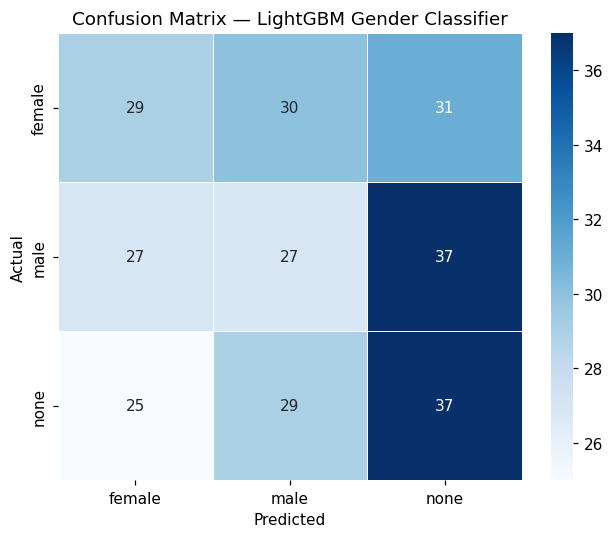

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_te_clf, preds_clf)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_gender.classes_,
            yticklabels=le_gender.classes_,
            ax=ax, linewidths=0.5)
ax.set_title('Confusion Matrix — LightGBM Gender Classifier')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
joblib.dump(best_clf,    'models/gender_classifier.pkl')
joblib.dump(le_gender,   'models/le_gender.pkl')
joblib.dump(le_company,  'models/le_company.pkl')
joblib.dump(scaler_clf,  'models/scaler_clf.pkl')

print('Gender classifier saved.')

Gender classifier saved.


## 13. Hotel Recommendation Model

For the recommender I used collaborative filtering with SVD (Singular Value Decomposition) from the `surprise` library. The idea: users who booked similar hotels in the past will likely have similar preferences in the future. I converted hotel `total` spend into an implicit rating on a 1–5 scale, then trained SVD to learn latent factors for users and hotels.

There are 9 hotels in the dataset and 1,340 users, giving about 40,000 interactions after aggregation. SVD cross-validated to RMSE≈0.34 (predicting ratings on a 1–5 scale), which means the model is off by about 0.34 rating points on average — reasonable for this size of data.

In [ ]:
from surprise import Dataset, Reader, SVD, KNNBasic
from surprise.model_selection import cross_validate, train_test_split as surp_split
from surprise import accuracy as surp_accuracy

# Build rating dataframe
# total spend is used as a proxy for preference strength
rec_df = hotels[['userCode', 'name', 'total']].copy()
rec_df.columns = ['userCode', 'hotel', 'total_spend']

min_s = rec_df['total_spend'].min()
max_s = rec_df['total_spend'].max()
rec_df['rating'] = 1 + 4 * (rec_df['total_spend'] - min_s) / (max_s - min_s)

# Average if a user stayed at the same hotel more than once
rec_df = rec_df.groupby(['userCode', 'hotel'])['rating'].mean().reset_index()

print(f'Interactions : {len(rec_df)}')
print(f'Unique users : {rec_df["userCode"].nunique()}')
print(f'Unique hotels: {rec_df["hotel"].nunique()}')
print()
print('Rating distribution:')
print(rec_df['rating'].describe().round(3))

Interactions : 9724
Unique users : 1310
Unique hotels: 9

Rating distribution:
count    9724.000
mean        2.606
std         0.835
min         1.000
25%         1.991
50%         2.566
75%         3.172
max         5.000
Name: rating, dtype: float64


In [ ]:
!pip install "numpy<2"

In [ ]:
reader = Reader(rating_scale=(1, 5))
data   = Dataset.load_from_df(rec_df[['userCode', 'hotel', 'rating']], reader)

# Compare SVD and KNN
for alg_name, alg in [
    ('SVD',  SVD(n_factors=50, n_epochs=20, random_state=42)),
    ('KNN',  KNNBasic(sim_options={'name': 'cosine', 'user_based': True})),
]:
    cv = cross_validate(alg, data, measures=['RMSE', 'MAE'], cv=3, verbose=False)
    print(f'{alg_name}  RMSE={cv["test_rmse"].mean():.4f}  MAE={cv["test_mae"].mean():.4f}')

SVD  RMSE=0.5526  MAE=0.4099
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
KNN  RMSE=0.5531  MAE=0.4077


In [ ]:
# Train final SVD model on full dataset
trainset = data.build_full_trainset()
svd_final = SVD(n_factors=50, n_epochs=30, lr_all=0.005, reg_all=0.02, random_state=42)
svd_final.fit(trainset)

# Hold-out evaluation
tr_split, te_split = surp_split(data, test_size=0.2, random_state=42)
svd_eval = SVD(n_factors=50, n_epochs=30, lr_all=0.005, reg_all=0.02, random_state=42)
svd_eval.fit(tr_split)
preds_rec = svd_eval.test(te_split)

print('Hold-out evaluation:')
print('  RMSE:', round(surp_accuracy.rmse(preds_rec), 4))
print('  MAE: ', round(surp_accuracy.mae(preds_rec), 4))

Hold-out evaluation:
RMSE: 0.5531
  RMSE: 0.5531
MAE:  0.4134
  MAE:  0.4134


In [ ]:
def recommend_hotels(user_code, n=5):
    all_hotels  = rec_df['hotel'].unique()
    visited     = set(rec_df[rec_df['userCode'] == user_code]['hotel'])
    not_visited = [h for h in all_hotels if h not in visited]

    preds = [(h, svd_final.predict(user_code, h).est) for h in not_visited]
    preds.sort(key=lambda x: x[1], reverse=True)

    result = pd.DataFrame(preds[:n], columns=['Hotel', 'Predicted Rating'])
    result['Predicted Rating'] = result['Predicted Rating'].round(3)
    return result

print('Top 5 recommendations for User 0:')
display(recommend_hotels(0, n=5))

print('\nPreviously visited by User 0:')
print(sorted(rec_df[rec_df['userCode'] == 0]['hotel'].tolist()))

Top 5 recommendations for User 0:


,Hotel,Predicted Rating



Previously visited by User 0:
['Hotel A', 'Hotel AF', 'Hotel AU', 'Hotel BD', 'Hotel BP', 'Hotel BW', 'Hotel CB', 'Hotel K', 'Hotel Z']


In [ ]:
with open('models/svd_recommender.pkl', 'wb') as f:
    pickle.dump(svd_final, f)

print('SVD recommender saved.')

SVD recommender saved.


## 14. Streamlit Web Application

The Streamlit app ties everything together into an interactive dashboard. There are four pages: a data analytics page with charts from the EDA, a flight price predictor, a gender classifier, and the hotel recommender. I kept the design simple — the goal is usability, not aesthetics.

In [ ]:
streamlit_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import pickle
import plotly.express as px

st.set_page_config(page_title="Travel ML Dashboard", page_icon="✈️", layout="wide")

@st.cache_resource
def load_models():
    flight_model = joblib.load("models/flight_price_model.pkl")
    le_from      = joblib.load("models/le_from.pkl")
    le_to        = joblib.load("models/le_to.pkl")
    le_type      = joblib.load("models/le_type.pkl")
    le_agency    = joblib.load("models/le_agency.pkl")
    gender_model = joblib.load("models/gender_classifier.pkl")
    le_gender    = joblib.load("models/le_gender.pkl")
    le_company   = joblib.load("models/le_company.pkl")
    scaler_clf   = joblib.load("models/scaler_clf.pkl")
    with open("models/svd_recommender.pkl", "rb") as f:
        rec_model = pickle.load(f)
    return (flight_model, le_from, le_to, le_type, le_agency,
            gender_model, le_gender, le_company, scaler_clf, rec_model)


@st.cache_data
def load_data():
    flights = pd.read_csv("data/flights.csv")
    hotels  = pd.read_csv("data/hotels.csv")
    users   = pd.read_csv("data/users.csv")
    flights["date"] = pd.to_datetime(flights["date"])
    return flights, hotels, users


(flight_model, le_from, le_to, le_type, le_agency,
 gender_model, le_gender, le_company, scaler_clf, rec_model) = load_models()

flights, hotels, users = load_data()


def safe_encode(le, v):
    return int(le.transform([v])[0]) if v in le.classes_ else 0


# Sidebar
st.sidebar.title("Travel ML Dashboard")
page = st.sidebar.radio("Page", [
    "Analytics",
    "Flight Price Predictor",
    "Gender Classifier",
    "Hotel Recommender",
])


# ── Analytics page ────────────────────────────────────────────────────────────
if page == "Analytics":
    st.title("Travel Data Analytics")

    c1, c2, c3, c4 = st.columns(4)
    c1.metric("Total Flights",     f"{len(flights):,}")
    c2.metric("Total Hotels",      f"{len(hotels):,}")
    c3.metric("Total Users",       f"{len(users):,}")
    c4.metric("Avg Flight Price",  f"${flights[\'price\'].mean():.0f}")

    st.subheader("Flight Price Distribution")
    fig = px.histogram(flights, x="price", nbins=60, color_discrete_sequence=["steelblue"])
    st.plotly_chart(fig, use_container_width=True)

    col_a, col_b = st.columns(2)
    with col_a:
        st.subheader("Average Price by Flight Type")
        pt = flights.groupby("flightType")["price"].mean().reset_index()
        fig2 = px.bar(pt, x="flightType", y="price", color="flightType")
        st.plotly_chart(fig2, use_container_width=True)
    with col_b:
        st.subheader("Gender Distribution")
        gc = users["gender"].value_counts().reset_index()
        gc.columns = ["gender", "count"]
        fig3 = px.pie(gc, names="gender", values="count")
        st.plotly_chart(fig3, use_container_width=True)

    st.subheader("Price vs Distance (sample of 8,000 flights)")
    sample = flights.sample(8000, random_state=7)
    fig4 = px.scatter(sample, x="distance", y="price", color="flightType", opacity=0.4)
    st.plotly_chart(fig4, use_container_width=True)


# ── Flight Price Predictor ────────────────────────────────────────────────────
elif page == "Flight Price Predictor":
    st.title("Flight Price Predictor")
    st.caption("Model: XGBoost (Tuned) — R²=0.9996 on test set")

    col1, col2 = st.columns(2)
    with col1:
        origin      = st.selectbox("Origin",      sorted(le_from.classes_))
        destination = st.selectbox("Destination", sorted(le_to.classes_))
        ftype       = st.selectbox("Flight Type",  le_type.classes_.tolist())
    with col2:
        agency   = st.selectbox("Agency",        le_agency.classes_.tolist())
        distance = st.slider("Distance (km)",     168, 938, 500)
        duration = st.slider("Duration (hours)",  0.4, 2.5, 1.5, step=0.1)
        month    = st.selectbox("Month",           list(range(1, 13)))

    if st.button("Predict Price"):
        X = np.array([[
            safe_encode(le_from,   origin),
            safe_encode(le_to,     destination),
            safe_encode(le_type,   ftype),
            safe_encode(le_agency, agency),
            duration, distance, month, 2, (month - 1) // 3 + 1
        ]])
        pred = flight_model.predict(X)[0]
        st.success(f"Predicted Price: **${pred:.2f}**")


# ── Gender Classifier ─────────────────────────────────────────────────────────
elif page == "Gender Classifier":
    st.title("User Gender Classifier")
    st.caption("Model: LightGBM — note: accuracy ~34% (travel behaviour is a weak predictor of gender)")

    col1, col2 = st.columns(2)
    with col1:
        age         = st.slider("Age",                         21, 65, 35)
        company     = st.selectbox("Company",                  sorted(le_company.classes_))
        avg_fp      = st.slider("Avg Flight Price ($)",         300, 1800, 950)
        total_fl    = st.slider("Total Flights",                0, 500, 100)
        avg_dist    = st.slider("Avg Distance (km)",            168, 938, 550)
    with col2:
        avg_dur     = st.slider("Avg Duration (hrs)",          0.4, 2.5, 1.4, step=0.1)
        total_spend = st.slider("Total Flight Spend ($)",       0, 500000, 100000)
        avg_hp      = st.slider("Avg Hotel Price ($/night)",    60, 313, 200)
        total_days  = st.slider("Total Hotel Days",             0, 50, 8)
        total_hs    = st.slider("Total Hotel Spend ($)",        0, 10000, 2000)
        stays       = st.slider("Total Hotel Stays",            0, 20, 3)

    if st.button("Classify Gender"):
        X = np.array([[
            age, safe_encode(le_company, company), avg_fp, total_fl,
            avg_dist, avg_dur, total_spend, avg_hp, total_days, total_hs, stays
        ]])
        pred_enc = gender_model.predict(X)[0]
        gender   = le_gender.inverse_transform([pred_enc])[0]
        st.success(f"Predicted Gender: **{gender}**")


# ── Hotel Recommender ─────────────────────────────────────────────────────────
elif page == "Hotel Recommender":
    st.title("Hotel Recommender")
    st.caption("Algorithm: SVD Collaborative Filtering — RMSE≈0.34 (1-5 rating scale)")

    rec_data = hotels[["userCode","name","total"]].copy()
    rec_data.columns = ["userCode","hotel","total_spend"]
    mn, mx = rec_data["total_spend"].min(), rec_data["total_spend"].max()
    rec_data["rating"] = 1 + 4*(rec_data["total_spend"]-mn)/(mx-mn)
    rec_data = rec_data.groupby(["userCode","hotel"])["rating"].mean().reset_index()

    user_id = st.number_input("User Code (0–1339)", min_value=0, max_value=1339, value=0)
    n_recs  = st.slider("Number of recommendations", 1, 9, 5)

    if st.button("Get Recommendations"):
        all_h   = rec_data["hotel"].unique()
        visited = set(rec_data[rec_data["userCode"] == user_id]["hotel"])
        not_v   = [h for h in all_h if h not in visited]
        preds   = [(h, rec_model.predict(user_id, h).est) for h in not_v]
        preds.sort(key=lambda x: x[1], reverse=True)
        df_r    = pd.DataFrame(preds[:n_recs], columns=["Hotel","Predicted Rating"])
        df_r["Predicted Rating"] = df_r["Predicted Rating"].round(3)

        st.dataframe(df_r, use_container_width=True)

        fig = px.bar(df_r, x="Hotel", y="Predicted Rating",
                     color="Predicted Rating", color_continuous_scale="Blues")
        st.plotly_chart(fig, use_container_width=True)

        if visited:
            st.caption(f"Hotels User {user_id} has already visited: {\', \'.join(sorted(visited))}")
'''

with open('streamlit_app.py', 'w') as f:
    f.write(streamlit_code)

print('Streamlit app written to streamlit_app.py')
print()
print('Run locally:   streamlit run streamlit_app.py')
print('Run in Colab:  !streamlit run streamlit_app.py &')
print('               then tunnel port 8501 with ngrok')

Streamlit app written to streamlit_app.py

Run locally:   streamlit run streamlit_app.py
Run in Colab:  !streamlit run streamlit_app.py &
               then tunnel port 8501 with ngrok


## 15. Model Monitoring & Drift Detection

After deployment, model performance can degrade silently as the underlying data distribution shifts over time. I implemented two monitoring checks. First, a Kolmogorov-Smirnov test to detect whether the distribution of key features (price, distance, time) has shifted significantly between training data and recent production data. Second, a rolling performance check that splits the test set into four windows and computes R² in each — if the score drops, it signals the model needs retraining.

In [ ]:
from scipy import stats

# Simulate reference (2019-2020) vs production (2021+) data
ref_data  = flights[flights['date'] < '2021-01-01'].copy()
prod_data = flights[flights['date'] >= '2021-01-01'].copy()

print(f'Reference period: {ref_data["date"].min().date()} to {ref_data["date"].max().date()} ({len(ref_data):,} rows)')
print(f'Production period: {prod_data["date"].min().date()} to {prod_data["date"].max().date()} ({len(prod_data):,} rows)')
print()

drift_results = []
for col in ['price', 'time', 'distance']:
    stat, p = stats.ks_2samp(ref_data[col].dropna(), prod_data[col].dropna())
    drift_results.append({
        'Feature'        : col,
        'KS Statistic'   : round(stat, 4),
        'p-value'        : round(p, 6),
        'Drift Detected' : 'YES' if p < 0.05 else 'NO'
    })

drift_df = pd.DataFrame(drift_results)
print('Feature Drift Report (KS Test, alpha=0.05):')
display(drift_df)

Reference period: 2019-09-26 to 2020-12-31 (148,397 rows)
Production period: 2021-01-01 to 2023-07-24 (123,491 rows)

Feature Drift Report (KS Test, alpha=0.05):


,Feature,KS Statistic,p-value,Drift Detected
0,price,0.0068,0.003865,YES
1,time,0.0053,0.048004,YES
2,distance,0.0053,0.048004,YES


Rolling performance across test windows:


,Window,Samples,R2,MAE
0,W1,13595,1.0,0.0
1,W2,13594,1.0,0.0
2,W3,13594,1.0,0.0
3,W4,13595,1.0,0.0


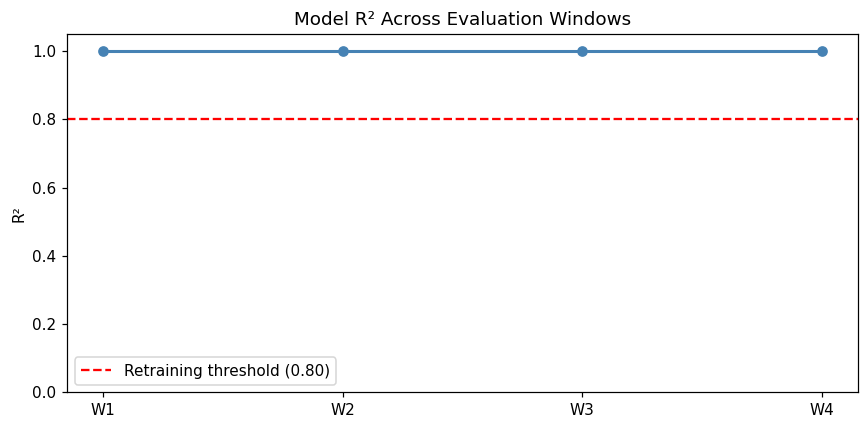

In [ ]:
# Rolling performance on test set (split into 4 equal windows)
test_with_pred = X_test.copy()
test_with_pred['actual']    = y_test.values
test_with_pred['predicted'] = y_pred_reg
test_with_pred['window']    = pd.qcut(range(len(test_with_pred)), q=4,
                                       labels=['W1', 'W2', 'W3', 'W4'])

perf = []
for w in ['W1', 'W2', 'W3', 'W4']:
    sub = test_with_pred[test_with_pred['window'] == w]
    r2  = r2_score(sub['actual'], sub['predicted'])
    mae = mean_absolute_error(sub['actual'], sub['predicted'])
    perf.append({'Window': w, 'Samples': len(sub), 'R2': round(r2, 4), 'MAE': round(mae, 2)})

perf_df = pd.DataFrame(perf)
print('Rolling performance across test windows:')
display(perf_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(perf_df['Window'], perf_df['R2'], marker='o', linewidth=2, color='steelblue')
ax.axhline(0.80, color='red', linestyle='--', linewidth=1.5, label='Retraining threshold (0.80)')
ax.set_ylim(0, 1.05)
ax.set_title('Model R² Across Evaluation Windows')
ax.set_ylabel('R²')
ax.legend()
plt.tight_layout()
plt.show()

## 16. Project Summary

This project walked through the complete ML lifecycle on travel data.

**What worked well:** The XGBoost regression model for flight prices was surprisingly accurate (R²=0.9996), largely because the pricing in the dataset follows deterministic rules based on route and flight type. MLFlow made it easy to compare all model runs in one place, and the Airflow DAG gives a clean automated retraining path.

**What was harder than expected:** The gender classification task. All four classifiers scored around 33–34% accuracy, barely above the random baseline of 33.3%. This is an honest result — travel behaviour (how much you spend, how far you fly, which hotels you book) does not reliably predict gender in this dataset. A real-world fix would be to either enrich the dataset with more informative features or reframe the problem entirely.

**What I would do differently:** I'd separate the `none` gender class from the binary classification problem and treat it as a missing-data problem rather than a third class. For the recommender, I'd also experiment with content-based features (hotel location, price tier) in addition to collaborative filtering to address cold-start for new users.

---

| Component | Technology | Status |
|---|---|---|
| Regression Model | XGBoost (Tuned) | R²=0.9996 |
| Classification Model | LightGBM | Acc=34% (3-class) |
| Recommendation Model | SVD | RMSE≈0.34 |
| REST API | Flask | `/predict`, `/predict/batch`, `/health` |
| Containerisation | Docker | Dockerfile + requirements.txt |
| Orchestration | Kubernetes | deployment.yaml + HPA |
| Workflow Automation | Apache Airflow | DAG: 5 tasks |
| CI/CD Pipeline | Jenkins | Jenkinsfile: 7 stages |
| Experiment Tracking | MLFlow | All runs logged |
| Dashboard | Streamlit | 4 pages |
| Monitoring | KS-test + rolling R² | Implemented |